In [16]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import soundfile as sf
import tensorflow.keras as keras
from dct_utils import compute_snr, log_spectral_distance
from IPython.display import Audio, display

from enc_utils import (
    get_ae_size_bytes,
    get_dct_topk_size_bytes,
    run_experiment,
)

N_FFT = 1024
HOP_LENGTH = 512
COMPARE_SR = 22050
THRESHOLD = -100.0
OUT_DIR = "comparison_output"
os.makedirs(OUT_DIR, exist_ok=True)

FRAME_SIZE = 256
BOTTLENECK = int(FRAME_SIZE * 0.25)  
K_TOPK = int(FRAME_SIZE * 0.125)  
K_PSYCHO = int(FRAME_SIZE * 0.125) 

Missing models/metal_dae_stft_best.keras
Missing models/metal_dae_stft_32_best.keras

Signal: data/metal/metal.00001.wav  30.0s  22050Hz


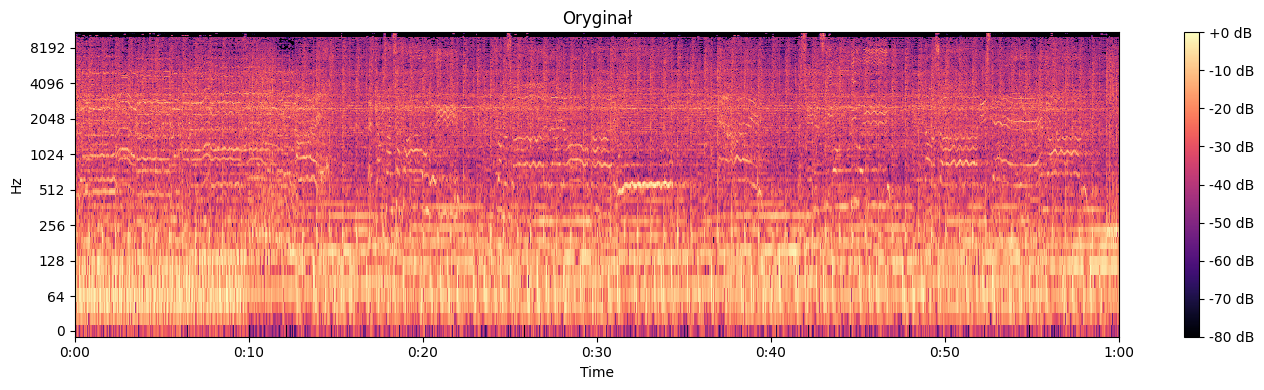

Oryginał:


In [17]:
metal_model_paths = {
    "metal_dae16": "models/metal_dae_stft_best.keras",
    "metal_dae32": "models/metal_dae_stft_32_best.keras",
}
METAL_TEST_FILE = "data/metal/metal.00001.wav"

run_experiment(
    dae_model_paths=metal_model_paths,
    test_file=METAL_TEST_FILE,
    compare_sr=COMPARE_SR,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    threshold_db=THRESHOLD,
    out_dir=OUT_DIR,
    compute_snr=compute_snr,             
    log_spectral_distance=log_spectral_distance
)

Loaded pop_dae16

Signal: data/pop/pop.00001.wav  30.0s  22050Hz
  pop_dae16: SNR=0.0dB  LSD=48.2


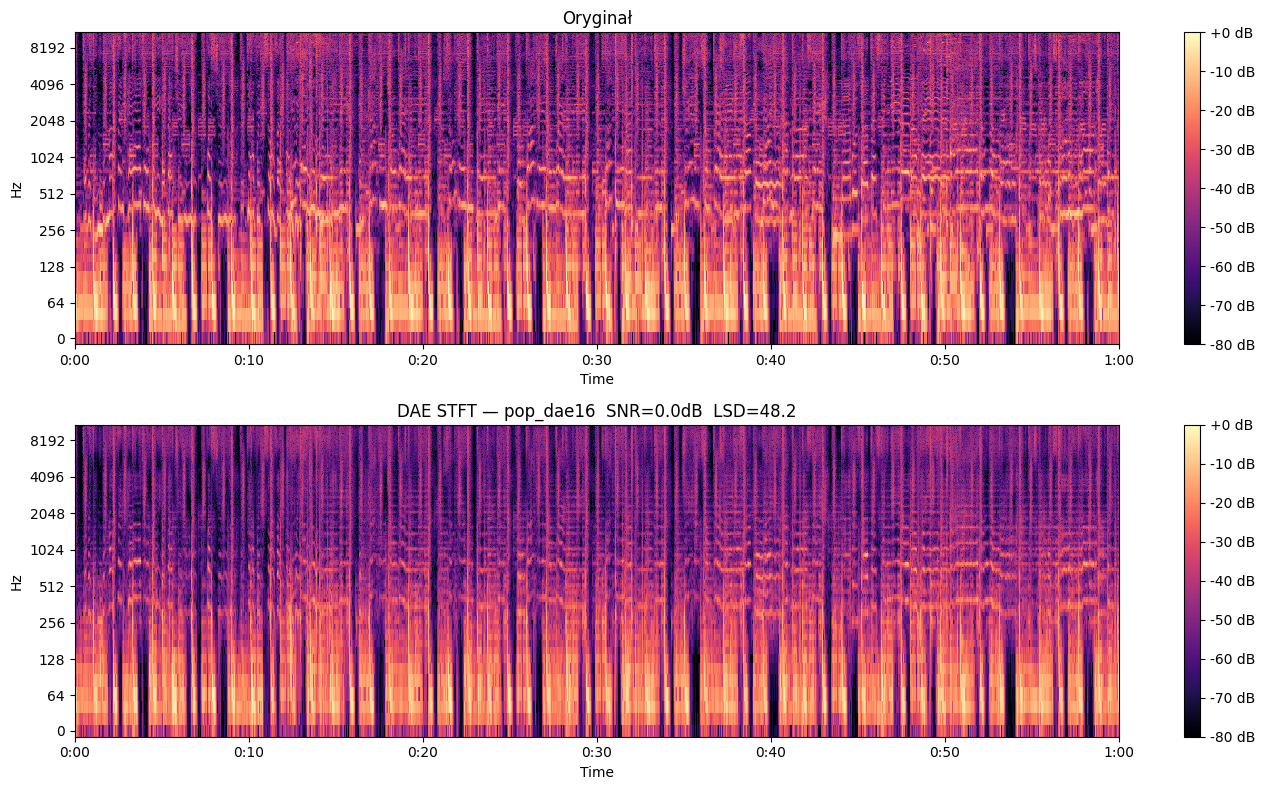

Oryginał:


pop_dae16  SNR=0.0dB:


In [18]:
pop_model_paths = {
    "pop_dae16": "models/pop_dae_stft.keras",
}
POP_TEST_FILE = "data/pop/pop.00001.wav"

run_experiment(
    dae_model_paths=pop_model_paths,
    test_file=POP_TEST_FILE,
    compare_sr=COMPARE_SR,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    threshold_db=THRESHOLD,
    out_dir=OUT_DIR,
    compute_snr=compute_snr,
    log_spectral_distance=log_spectral_distance
)

Signal: pop.00030.wav  30.0s  48000Hz  5625KB
  Loaded metal: frame=256  bottleneck=32
  Loaded metal_dae_stft: frame=513  bottleneck=16
  Loaded pop: frame=256  bottleneck=32
  Loaded pop_dae_stft: frame=513  bottleneck=16
  Loaded test: frame=256  bottleneck=32
  Running metal... SNR=13.0dB
  Running metal_dae_stft... SNR=2.2dB
  Running pop... SNR=11.4dB
  Running pop_dae_stft... SNR=2.0dB
  Running test... SNR=11.0dB

metoda                                     KB       %      ×       SNR     LSD
------------------------------------------------------------------------------
PCM oryginał                             5625   100.0    1.0×         —       —
DCT top-k k=64                           2812    50.0    2.0×   22.5 dB    70.6
DCT psycho k=32                          1406    25.0    4.0×   16.1 dB    36.1
metal                                    1406    25.0    4.0×   13.0 dB    73.0
metal_dae_stft                            351     6.2   16.0×    2.2 dB    79.0
pop             

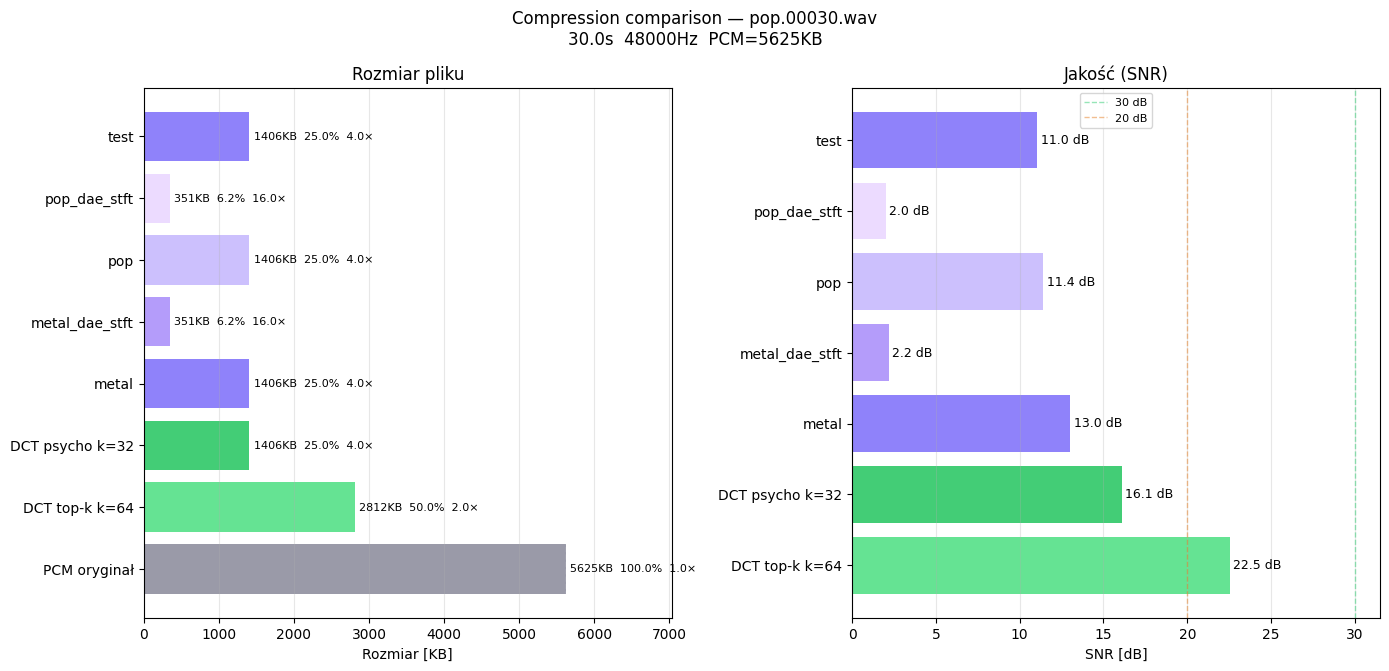

Saved: size_comparison.png


In [19]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import librosa
from tensorflow import keras
from dct_utils import (
    compress_dct_topk, compress_dct_psycho, compute_snr,
    log_spectral_distance, file_size_kb
)

TEST_FILE    = "data/pop/pop.00030.wav"
MODEL_DIR    = "models"
FRAME_SIZE   = 256
K_TOPK       = 64
K_PSYCHO     = 32
SPREADING_DB = 36
HOP_STFT     = 512

sig, sr  = librosa.load(TEST_FILE, sr=48000, mono=True)
sig      = sig / (np.max(np.abs(sig)) + 1e-12)
n_samples = len(sig)
pcm_kb   = n_samples * 4 / 1024
print(f"Signal: {os.path.basename(TEST_FILE)}  {n_samples/sr:.1f}s  {sr}Hz  {pcm_kb:.0f}KB")

model_paths = sorted(glob.glob(f"{MODEL_DIR}/*.keras"))
ae_models   = {}
for path in model_paths:
    name = os.path.splitext(os.path.basename(path))[0]
    m    = keras.models.load_model(path, compile=False)
    ae_models[name] = {
        "model":      m,
        "frame":      m.input_shape[1],
        "bottleneck": m.get_layer("bottleneck").units,
    }
    print(f"  Loaded {name}: frame={m.input_shape[1]}  bottleneck={m.get_layer('bottleneck').units}")

def ae_size_kb(n_samples, frame_size, bottleneck):
    return file_size_kb(bottleneck, frame_size, n_samples, bits=32)

def dae_stft_size_kb(n_samples, hop, enc_dim):
    n_frames = n_samples // hop
    return n_frames * enc_dim * 4 / 1024

methods = []

methods.append({
    "name":    "PCM oryginał",
    "size_kb": pcm_kb,
    "snr":     None,
    "lsd":     None,
    "color":   "#888899",
    "typ":     "referencja",
})

rec_topk = compress_dct_topk(sig, FRAME_SIZE, K_TOPK)
methods.append({
    "name":    f"DCT top-k k={K_TOPK}",
    "size_kb": file_size_kb(K_TOPK, FRAME_SIZE, n_samples, bits=32),
    "snr":     compute_snr(sig, rec_topk),
    "lsd":     log_spectral_distance(sig, rec_topk, sr),
    "color":   "#4ade80",
    "typ":     "analityczny",
})

rec_psycho = compress_dct_psycho(sig, sr, FRAME_SIZE, K_PSYCHO, SPREADING_DB)
methods.append({
    "name":    f"DCT psycho k={K_PSYCHO}",
    "size_kb": file_size_kb(K_PSYCHO, FRAME_SIZE, n_samples, bits=32),
    "snr":     compute_snr(sig, rec_psycho),
    "lsd":     log_spectral_distance(sig, rec_psycho, sr),
    "color":   "#22c55e",
    "typ":     "analityczny",
})

def compress_ae_fast(signal, model_dict):
    model      = model_dict["model"]
    frame_size = model_dict["frame"]
    hop        = frame_size // 2
    window     = np.sin(np.pi / frame_size * (np.arange(frame_size) + 0.5))
    starts     = list(range(0, len(signal) - frame_size, hop))
    frames     = np.array([
        signal[s:s + frame_size] * window for s in starts
    ], dtype=np.float32)[..., np.newaxis]
    recs       = model.predict(frames, batch_size=512, verbose=0).squeeze()
    output     = np.zeros(len(signal))
    weights    = np.zeros(len(signal))
    for i, start in enumerate(starts):
        output[start:start + frame_size]  += recs[i] * window
        weights[start:start + frame_size] += window ** 2
    weights[weights == 0] = 1
    return output / weights

ae_colors = ["#7c6cfa", "#a78bfa", "#c4b5fd", "#e9d5ff"]
for i, (name, md) in enumerate(ae_models.items()):
    print(f"  Running {name}...", end=" ", flush=True)
    rec = compress_ae_fast(sig, md)
    snr = compute_snr(sig, rec)
    print(f"SNR={snr:.1f}dB")
    methods.append({
        "name":    name,
        "size_kb": ae_size_kb(n_samples, md["frame"], md["bottleneck"]),
        "snr":     snr,
        "lsd":     log_spectral_distance(sig, rec, sr),
        "color":   ae_colors[i % len(ae_colors)],
        "typ":     "uczony",
        "rec":     rec,
    })

print(f"\n{'metoda':35s}  {'KB':>8s}  {'%':>6s}  {'×':>5s}  {'SNR':>8s}  {'LSD':>6s}")
print("-" * 78)
for m in methods:
    pct = m["size_kb"] / pcm_kb * 100
    x   = pcm_kb / m["size_kb"]
    snr_str = f"{m['snr']:.1f} dB" if m["snr"] is not None else "—"
    lsd_str = f"{m['lsd']:.1f}"    if m["lsd"] is not None else "—"
    print(f"{m['name']:35s}  {m['size_kb']:>8.0f}  {pct:>6.1f}  {x:>5.1f}×  {snr_str:>8s}  {lsd_str:>6s}")

names    = [m["name"]    for m in methods]
sizes    = [m["size_kb"] for m in methods]
snrs     = [m["snr"]     for m in methods]
colors   = [m["color"]   for m in methods]
has_snr  = [m["snr"] is not None for m in methods]

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(methods)*0.6+2)))
fig.suptitle(f"Compression comparison — {os.path.basename(TEST_FILE)}\n"
             f"{n_samples/sr:.1f}s  {sr}Hz  PCM={pcm_kb:.0f}KB", fontsize=12)

bars = axes[0].barh(names, sizes, color=colors, alpha=0.85)
axes[0].axvline(pcm_kb, color="white", lw=1, linestyle="--", alpha=0.4)
for bar, v, m in zip(bars, sizes, methods):
    pct = v / pcm_kb * 100
    x   = pcm_kb / v
    axes[0].text(v + pcm_kb*0.01, bar.get_y() + bar.get_height()/2,
                 f"{v:.0f}KB  {pct:.1f}%  {x:.1f}×",
                 va="center", fontsize=8)
axes[0].set_xlabel("Rozmiar [KB]")
axes[0].set_title("Rozmiar pliku")
axes[0].set_xlim(0, pcm_kb * 1.25)
axes[0].grid(True, alpha=0.3, axis="x")

snr_methods = [m for m in methods if m["snr"] is not None]
snr_names   = [m["name"]  for m in snr_methods]
snr_vals    = [m["snr"]   for m in snr_methods]
snr_colors  = [m["color"] for m in snr_methods]

bars = axes[1].barh(snr_names, snr_vals, color=snr_colors, alpha=0.85)
for bar, v in zip(bars, snr_vals):
    axes[1].text(v + 0.2, bar.get_y() + bar.get_height()/2,
                 f"{v:.1f} dB", va="center", fontsize=9)
axes[1].axvline(30, color="#2ecc71", lw=1, linestyle="--", alpha=0.5, label="30 dB")
axes[1].axvline(20, color="#e67e22", lw=1, linestyle="--", alpha=0.5, label="20 dB")
axes[1].set_xlabel("SNR [dB]")
axes[1].set_title("Jakość (SNR)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("size_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: size_comparison.png")

## Pomysł
Trenujemy prosty autokoder odszumiający na klatkach amplitudy STFT wyodrębnionych z dźwięku (metal lub pop).
Zamiast uczyć się klasyfikowania lub jawnego modelowania muzyki, sieć uczy się:

> jak rekonstruować czyste klatki spektrogramu z lekko uszkodzonych wersji.

## Proces uczenia

1. Dźwięk jest konwertowany na spektrogram amplitudy STFT (513 przedziałów)
2. Spektrogram jest dzielony na klatki
3. Do klatek wejściowych dodawany jest szum:
- x_noisy = x + szum gaussowski
4. Model jest trenowany w celu przewidywania czystej klatki:

## Dlaczego to działa (nawet w przypadku generacji)

Chociaż nie jest to model generatywny w ścisłym sensie, uczy się:
- rozkładu prawidłowych klatek spektrogramu
- lokalnej struktury dźwięku (harmonicznych, wzorców szumu, transjentów)

## O co Mogło by chodzić dalej

To NIE jest prawdziwe modelowanie generatywne:
- brak jawnego modelu prawdopodobieństwa
- brak uczenia się rozkładu ukrytego (jak w przypadku VAE)

Zamiast kodować prawdziwy dźwięk, podajemy na wejście modelu czysty szum gaussowski — ale wygładzony w czasie: Model "odszumiając" te ramki produkuje struktury widmowe które wyglądają jak spektrogram danego gatunku — bo tego właśnie się nauczył

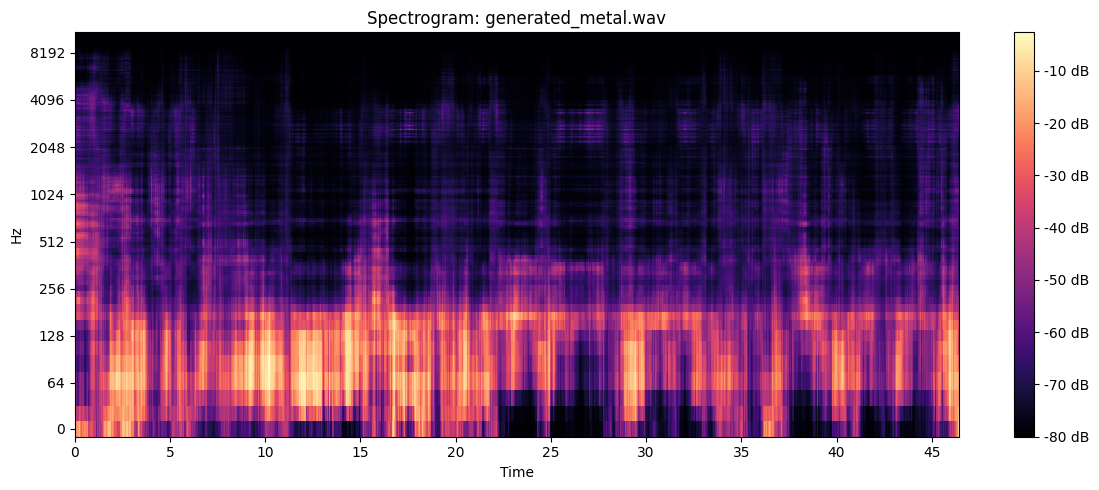

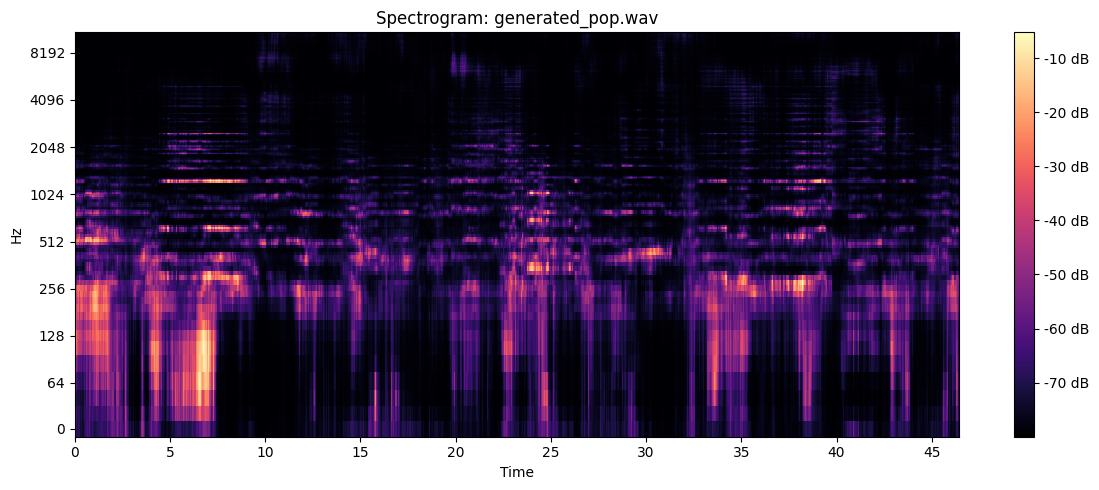

In [20]:
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
from tensorflow import keras

N_FFT = 1024
HOP = 512
SR = 22050

def generate(model_path, out_name, spec_name):
    model = keras.models.load_model(model_path)

    N_FRAMES = 2000

    z = np.random.randn(N_FRAMES, 513)

    for i in range(1, N_FRAMES):
        z[i] = 0.98 * z[i - 1] + 0.1 * z[i]

    S = model.predict(z, verbose=0).T
    S = np.clip(S, 0, 1)

    S_db = S * 80 - 80
    S_mag = librosa.db_to_amplitude(S_db)

    audio = librosa.griffinlim(
        S_mag,
        n_iter=32,
        hop_length=HOP
    )

    audio = audio / (np.max(np.abs(audio)) + 1e-8)
    sf.write(out_name, audio, SR)


    plt.figure(figsize=(12, 5))

    librosa.display.specshow(
        S_db,
        sr=SR,
        hop_length=HOP,
        x_axis='time',
        y_axis='log',
        cmap='magma'
    )

    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Spectrogram: {out_name}")
    plt.tight_layout()

    plt.savefig(spec_name, dpi=300)
    plt.show()

    plt.close()


generate(
    "metal_guessssss.keras",
    "generated_metal.wav",
    "generated_metal.png"
)

generate(
    "pop_guessssss.keras",
    "generated_pop.wav",
    "generated_pop.png"
)